In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
dataset = pd.read_csv("/content/public_transport_delays.csv")

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   object 
 1   date                        2000 non-null   object 
 2   time                        2000 non-null   object 
 3   transport_type              2000 non-null   object 
 4   route_id                    2000 non-null   object 
 5   origin_station              2000 non-null   object 
 6   destination_station         2000 non-null   object 
 7   scheduled_departure         2000 non-null   object 
 8   scheduled_arrival           2000 non-null   object 
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   object 
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 

In [ ]:
dataset.describe()

,actual_departure_delay_min,actual_arrival_delay_min,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,delayed
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,8.688000,13.318000,15.121350,64.714000,29.300500,9.860700,6420.250000,50.244000,0.089500,0.272000,2.976000,0.749500
std,6.268118,9.289727,11.479424,20.334747,17.264015,5.781373,15198.306129,29.225751,0.285535,0.445101,1.990328,0.433409
min,-2.000000,-3.000000,-5.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,5.000000,5.100000,46.000000,15.000000,4.900000,0.000000,25.000000,0.000000,0.000000,1.000000,0.000000
50%,9.000000,13.000000,15.300000,65.000000,29.000000,9.700000,0.000000,50.000000,0.000000,0.000000,3.000000,1.000000
75%,14.000000,21.000000,24.800000,83.000000,45.000000,14.800000,2000.000000,76.000000,0.000000,1.000000,5.000000,1.000000
max,19.000000,29.000000,35.000000,99.000000,59.000000,20.000000,50000.000000,99.000000,1.000000,1.000000,6.000000,1.000000


In [ ]:
dataset.head()

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,NaN,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NaN,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,NaN,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,NaN,500,46,0,0,6,Spring,1


## Detailed Exploratory Data Analysis (EDA)

### 1. Target Variable Distribution

This section visualizes the distribution of our target variable, `delayed`, to understand its balance. As seen previously, this is handled by cell `d388f8aa`.

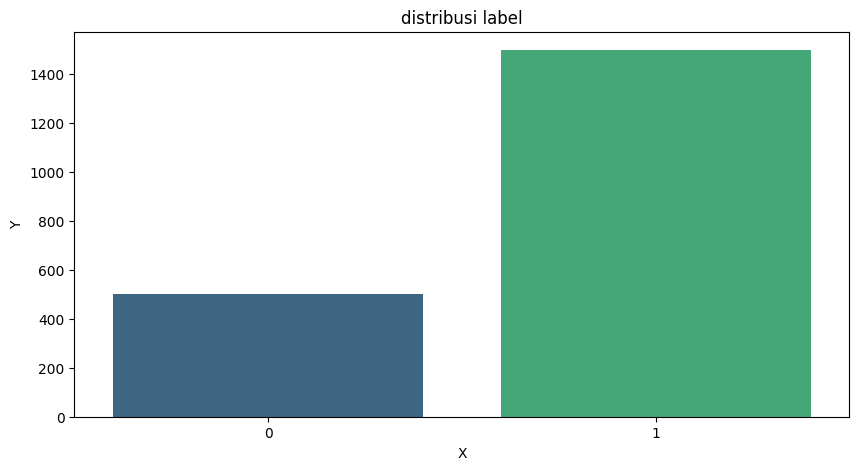

delayed
1    0.7495
0    0.2505
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(x='delayed', data=dataset, palette='viridis', hue='delayed', legend=False)
plt.title("distribusi label")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()
print(dataset['delayed'].value_counts(normalize=True))

This shows if our target variable is balanced or imbalanced. Next, let's examine some categorical features and their relationship with the `delayed` status.

### 2. Numerical Feature Distributions

We'll visualize the distributions of numerical features using histograms to understand their spread, skewness, and presence of outliers.

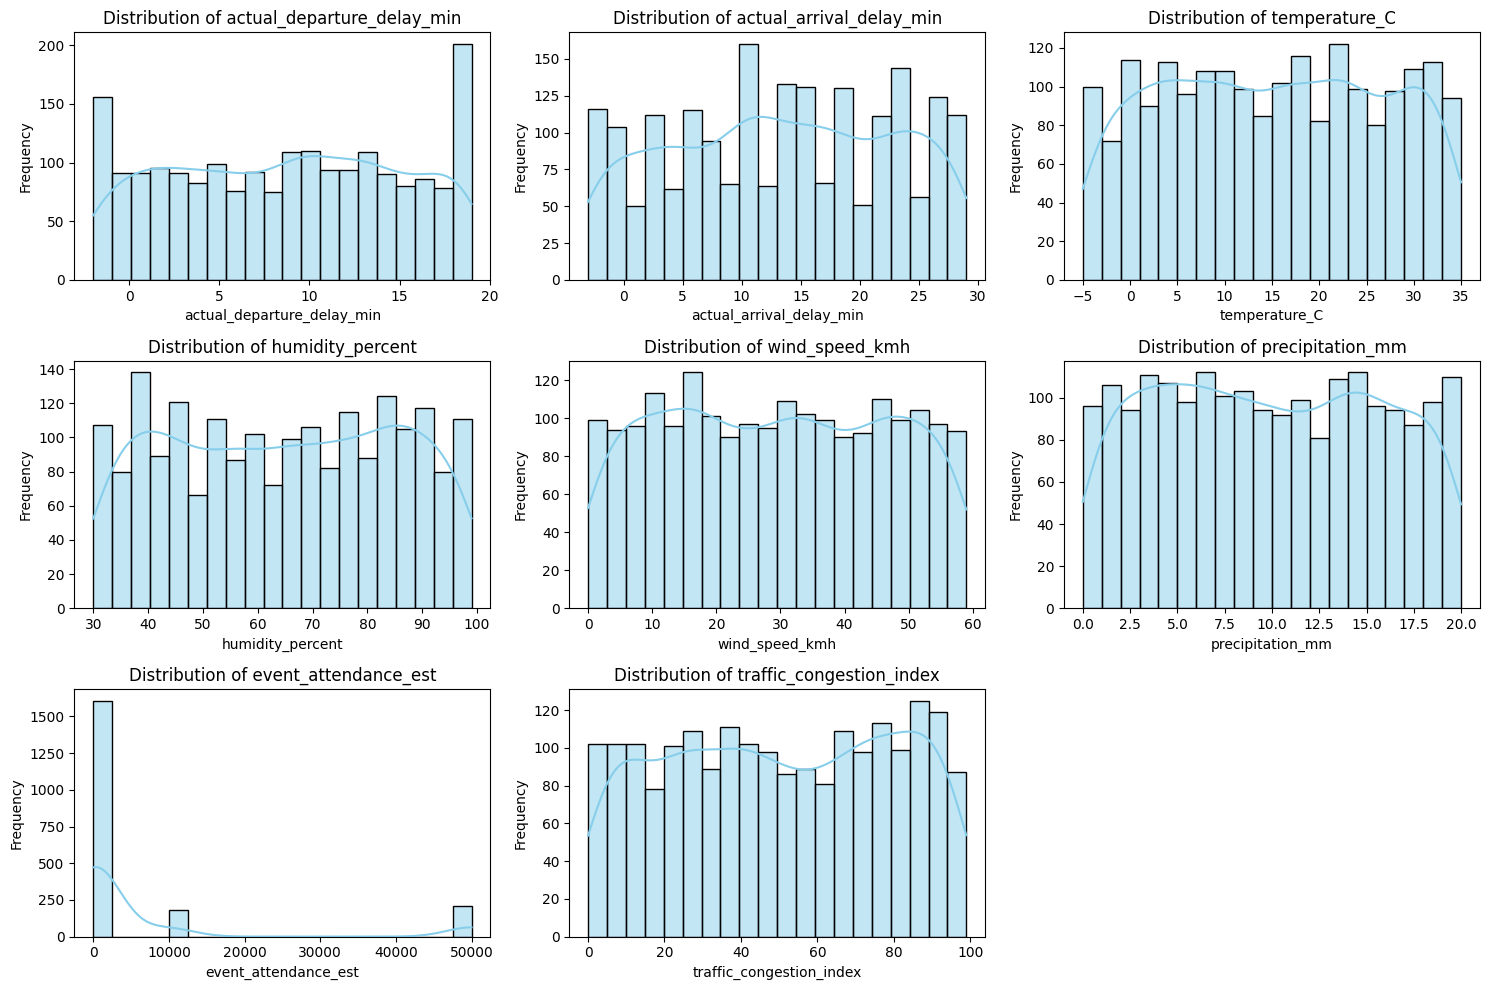

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_features_for_dist = [
    'actual_departure_delay_min', 'actual_arrival_delay_min',
    'temperature_C', 'humidity_percent', 'wind_speed_kmh',
    'precipitation_mm', 'event_attendance_est', 'traffic_congestion_index'
]

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features_for_dist):
    plt.subplot(3, 3, i + 1)
    sns.histplot(dataset[col], kde=True, bins=20, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### 3. Categorical Feature Distributions

Here, we'll examine the frequency distribution of categorical features using count plots.

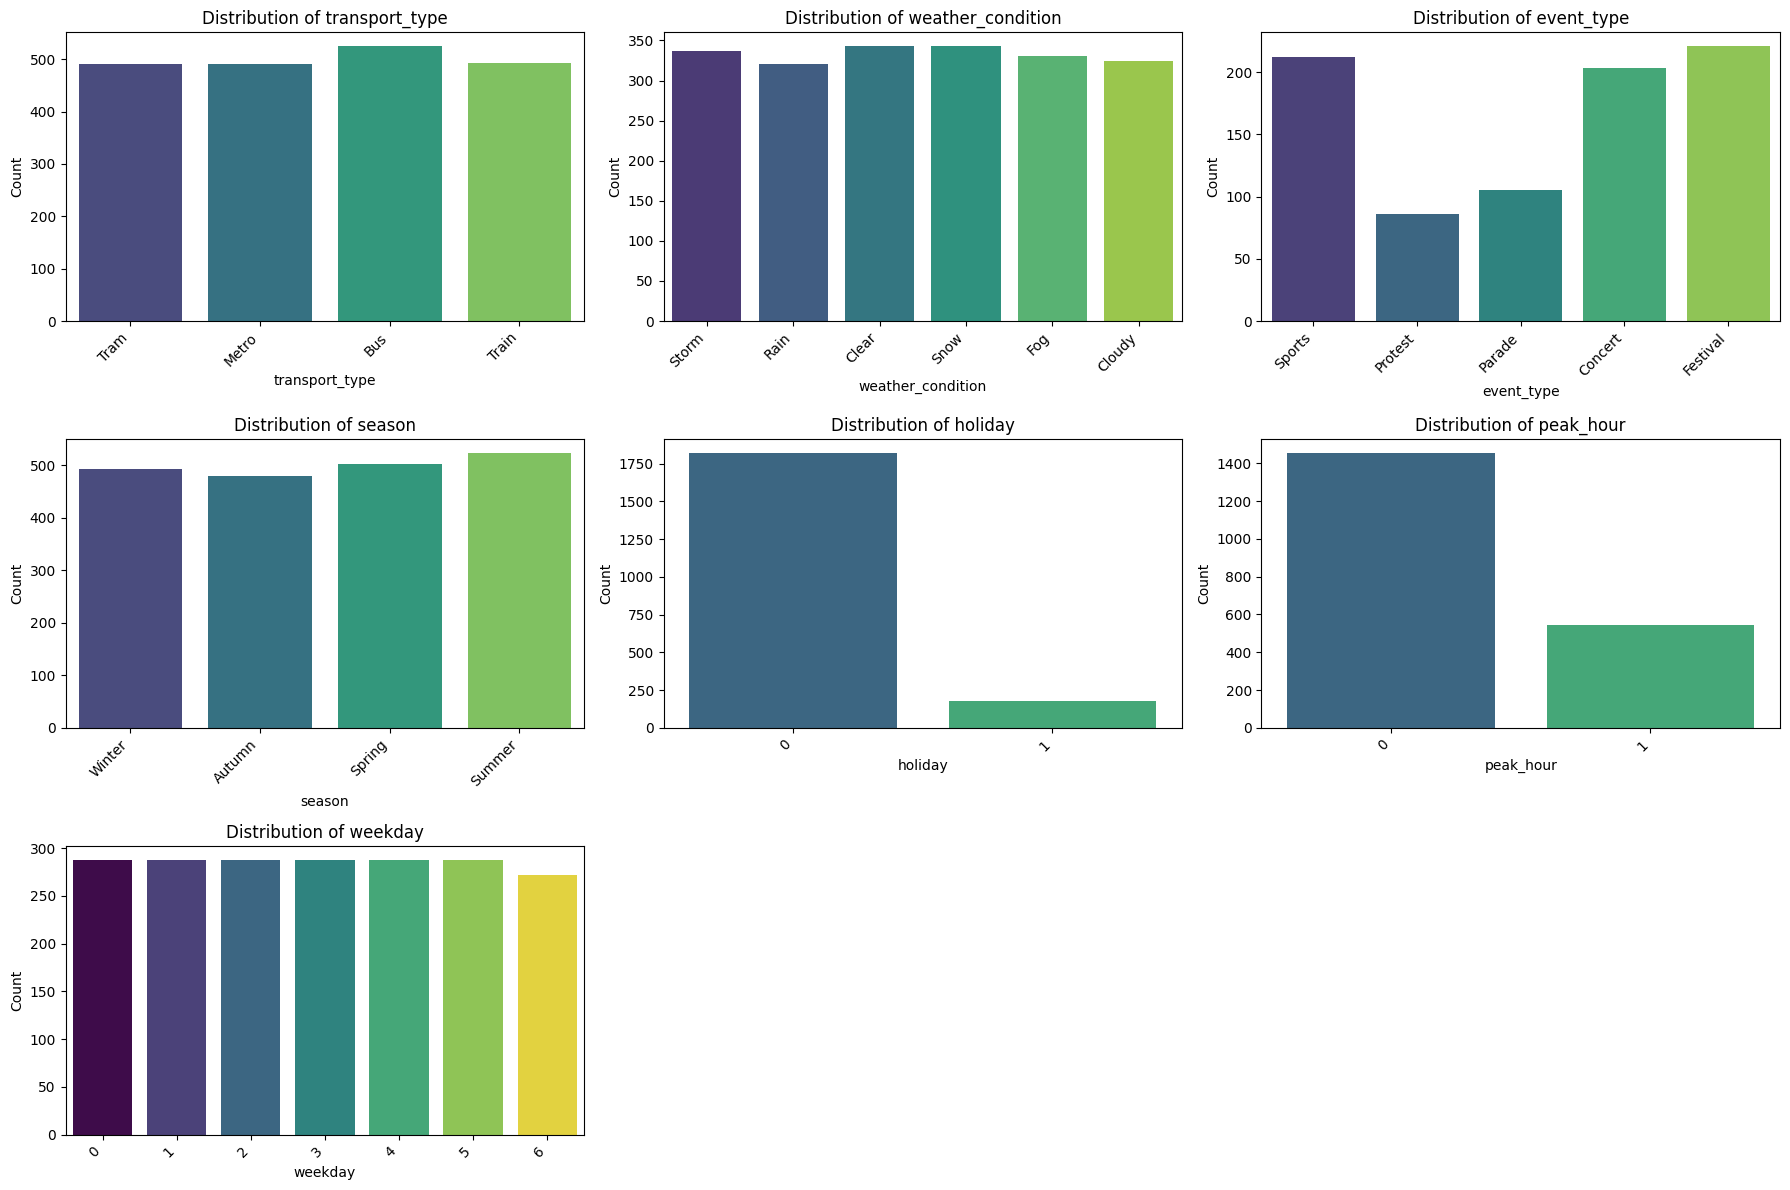

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_features_for_dist = [
    'transport_type', 'weather_condition', 'event_type', 'season',
    'holiday', 'peak_hour', 'weekday'
]

plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_features_for_dist):
    plt.subplot(3, 3, i + 1)
    sns.countplot(x=col, data=dataset, palette='viridis', hue=col, legend=False)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4. Numerical Features vs. Target Variable

Box plots will be used to understand how the distribution of numerical features varies with the `delayed` status.

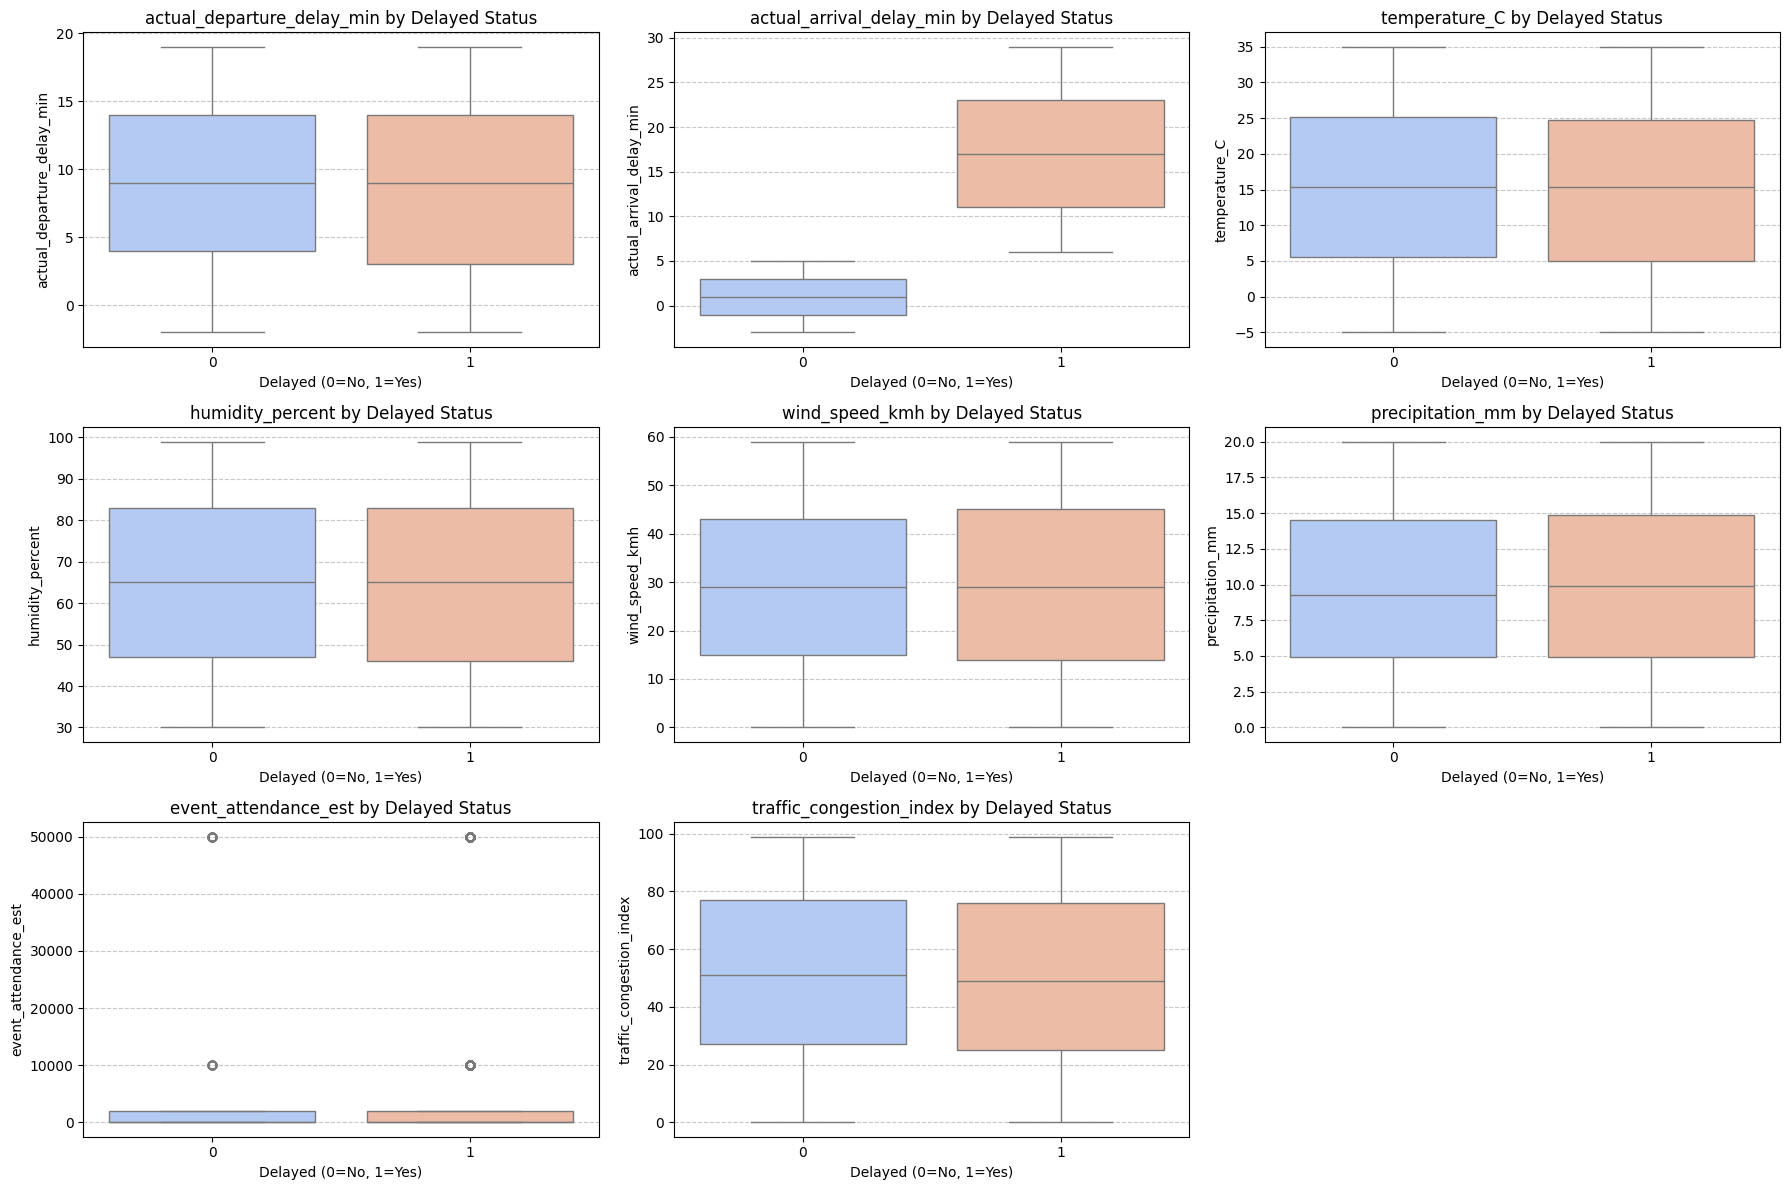

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_features_for_vs_target = [
    'actual_departure_delay_min', 'actual_arrival_delay_min',
    'temperature_C', 'humidity_percent', 'wind_speed_kmh',
    'precipitation_mm', 'event_attendance_est', 'traffic_congestion_index'
]

plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_features_for_vs_target):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x='delayed', y=col, data=dataset, palette='coolwarm', hue='delayed', legend=False)
    plt.title(f'{col} by Delayed Status')
    plt.xlabel('Delayed (0=No, 1=Yes)')
    plt.ylabel(col)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 5. Categorical Features vs. Target Variable

We'll use count plots with `hue` to visualize the relationship between categorical features and the `delayed` status.

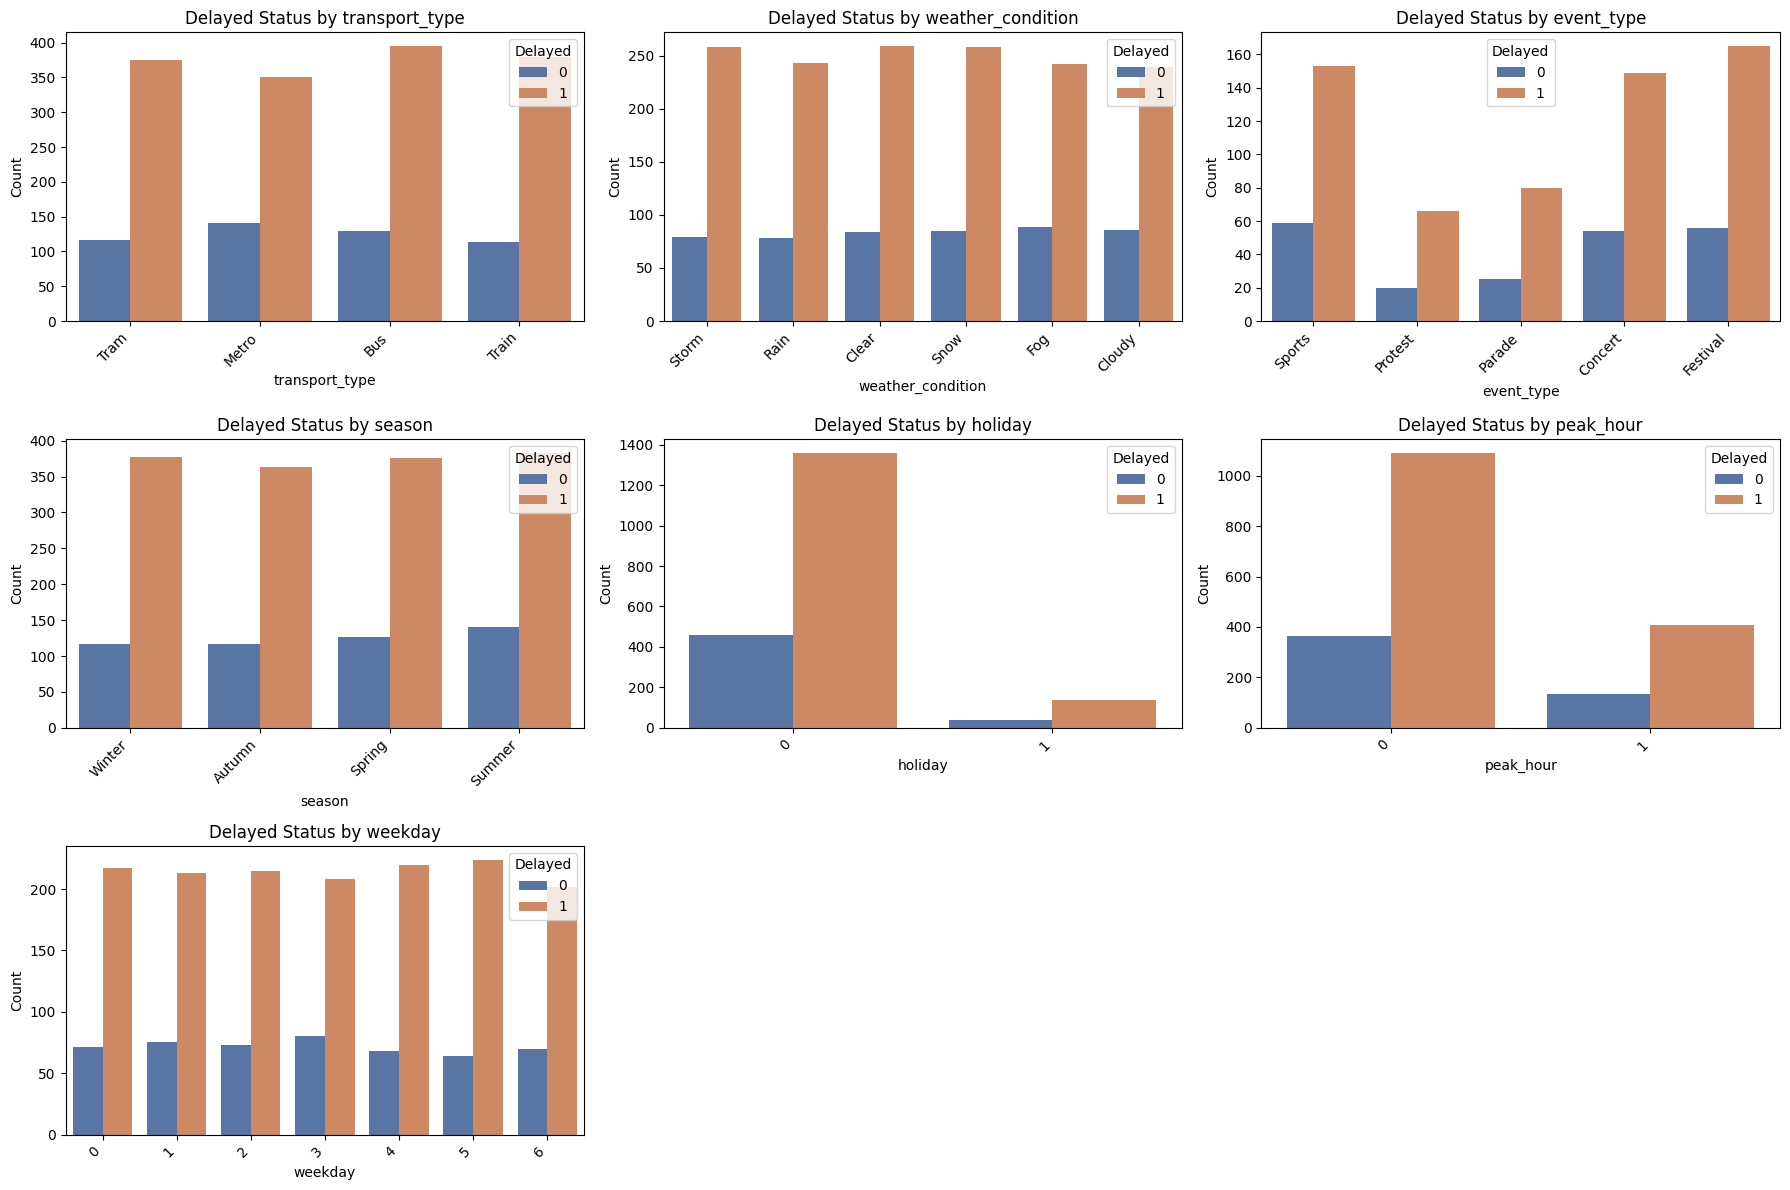

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_features_for_vs_target = [
    'transport_type', 'weather_condition', 'event_type', 'season',
    'holiday', 'peak_hour', 'weekday'
]

plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_features_for_vs_target):
    plt.subplot(3, 3, i + 1)
    sns.countplot(x=col, hue='delayed', data=dataset, palette='deep')
    plt.title(f'Delayed Status by {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Delayed')
plt.tight_layout()
plt.show()

### 6. Correlation Matrix

A heatmap will illustrate the correlation between numerical features.

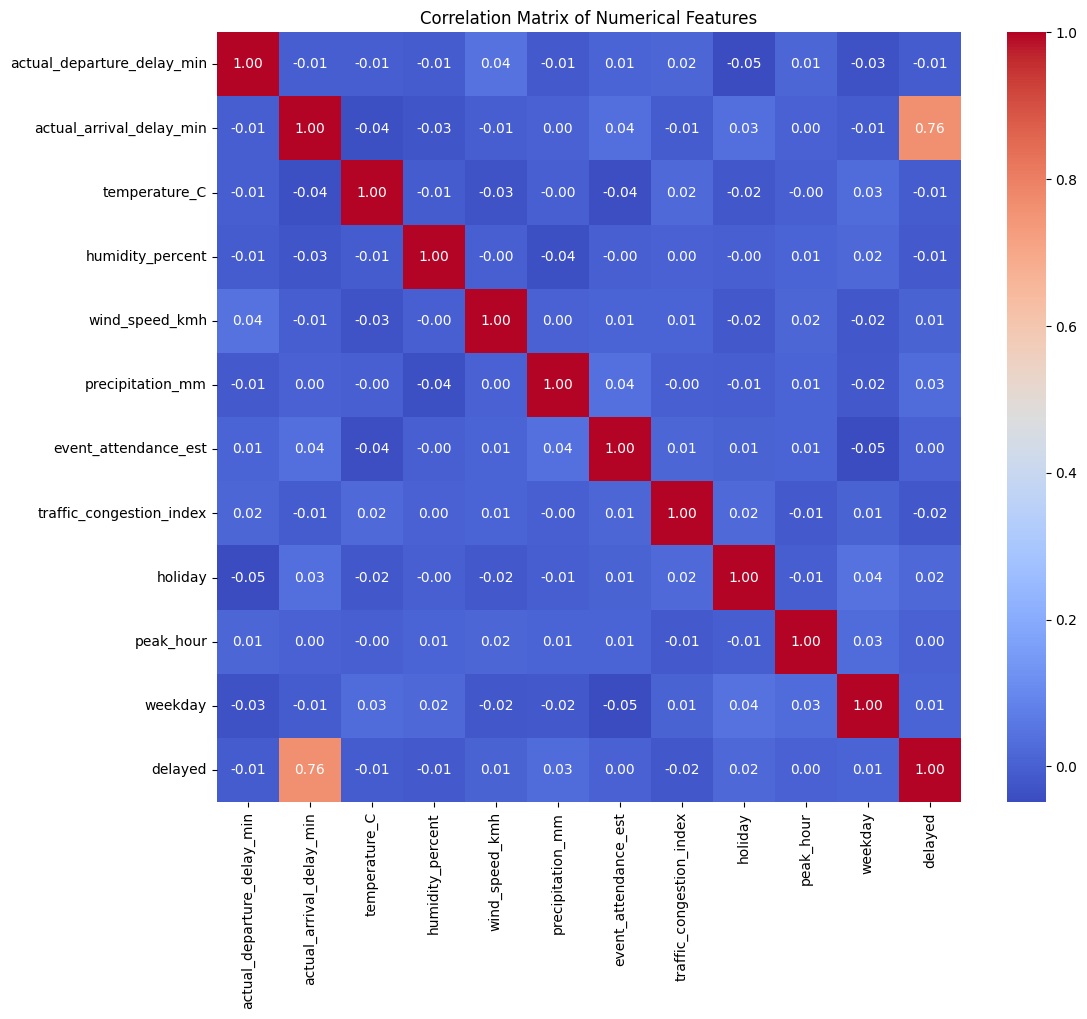

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols_for_corr = [
    'actual_departure_delay_min', 'actual_arrival_delay_min',
    'temperature_C', 'humidity_percent', 'wind_speed_kmh',
    'precipitation_mm', 'event_attendance_est', 'traffic_congestion_index',
    'holiday', 'peak_hour', 'weekday', 'delayed'
]

plt.figure(figsize=(12, 10))
sns.heatmap(dataset[numerical_cols_for_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### 7. Missing Values and Duplicates Check

We will re-check for missing values (referencing previous findings) and also check for duplicate rows in the dataset.

In [ ]:
print("Missing values per column (before specific preprocessing):")
print(dataset.isnull().sum())

print("\nNumber of duplicate rows:")
print(dataset.duplicated().sum())

Missing values per column (before specific preprocessing):
trip_id                          0
date                             0
time                             0
transport_type                   0
route_id                         0
origin_station                   0
destination_station              0
scheduled_departure              0
scheduled_arrival                0
actual_departure_delay_min       0
actual_arrival_delay_min         0
weather_condition                0
temperature_C                    0
humidity_percent                 0
wind_speed_kmh                   0
precipitation_mm                 0
event_type                    1173
event_attendance_est             0
traffic_congestion_index         0
holiday                          0
peak_hour                        0
weekday                          0
season                           0
delayed                          0
dtype: int64

Number of duplicate rows:
0


# Preprocessing

In [ ]:
dataset.dropna(subset=['event_type'], inplace=True)
print("Null values after dropping rows with null event_type:")
print(dataset.isnull().sum())

Null values after dropping rows with null event_type:
trip_id                       0
date                          0
time                          0
transport_type                0
route_id                      0
origin_station                0
destination_station           0
scheduled_departure           0
scheduled_arrival             0
actual_departure_delay_min    0
actual_arrival_delay_min      0
weather_condition             0
temperature_C                 0
humidity_percent              0
wind_speed_kmh                0
precipitation_mm              0
event_type                    0
event_attendance_est          0
traffic_congestion_index      0
holiday                       0
peak_hour                     0
weekday                       0
season                        0
delayed                       0
dtype: int64


# One-Hot Encoding

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd

y = dataset['delayed']
X = dataset.drop(columns=['delayed', 'trip_id', 'date', 'time', 'scheduled_departure', 'scheduled_arrival'])

categorical_features = X.select_dtypes(include='object').columns.tolist()
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

X_processed = preprocessor.fit_transform(X)

encoded_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(encoded_feature_names) + numerical_features

X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names)

print("Features after One-Hot Encoding and original numerical features:")
print(X_processed_df.head())

Features after One-Hot Encoding and original numerical features:
   transport_type_Bus  transport_type_Metro  transport_type_Train  \
0                 1.0                   0.0                   0.0   
1                 0.0                   1.0                   0.0   
2                 1.0                   0.0                   0.0   
3                 0.0                   0.0                   0.0   
4                 0.0                   0.0                   0.0   

   transport_type_Tram  route_id_Route_1  route_id_Route_10  \
0                  0.0               0.0                0.0   
1                  0.0               0.0                0.0   
2                  0.0               0.0                0.0   
3                  1.0               0.0                0.0   
4                  1.0               0.0                0.0   

   route_id_Route_11  route_id_Route_12  route_id_Route_13  route_id_Route_14  \
0                0.0                0.0                0.0  

# Log Transformation untuk nemerical features

In [ ]:
import numpy as np

log_transform_cols = [
    'humidity_percent',
    'wind_speed_kmh',
    'precipitation_mm',
    'event_attendance_est',
    'traffic_congestion_index'
]

X_log_transformed_df = X_processed_df.copy()

for col in log_transform_cols:
    if col in X_log_transformed_df.columns:
        X_log_transformed_df[col] = np.log1p(X_log_transformed_df[col])
    else:
        print(f"Warning: Column '{col}' not found in X_log_transformed_df and was skipped.")

print("Descriptive statistics after log transformation (selected columns):")
print(X_log_transformed_df[log_transform_cols].describe())

Descriptive statistics after log transformation (selected columns):
       humidity_percent  wind_speed_kmh  precipitation_mm  \
count        827.000000      827.000000        827.000000   
mean           4.129117        3.136347          2.181058   
std            0.334993        0.881745          0.710465   
min            3.433987        0.000000          0.000000   
25%            3.850148        2.772589          1.774952   
50%            4.189655        3.401197          2.360854   
75%            4.418841        3.806662          2.760010   
max            4.605170        4.094345          3.044522   

       event_attendance_est  traffic_congestion_index  
count            827.000000                827.000000  
mean               3.360317                  3.669728  
std                4.327609                  0.891706  
min                0.000000                  0.000000  
25%                0.000000                  3.276967  
50%                0.000000                  3

### 4. Scaling Numerical Features

We will apply StandardScaler to normalize the numerical features. This is important for many machine learning algorithms that are sensitive to the scale of input features.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaled_features_names = [col for col in X_log_transformed_df.columns if col not in preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)]

scaler = StandardScaler()
X_scaled = X_log_transformed_df.copy()
X_scaled[scaled_features_names] = scaler.fit_transform(X_log_transformed_df[scaled_features_names])

X_scaled_df = X_scaled

print("Descriptive statistics after scaling (selected numerical columns):")
print(X_scaled_df[scaled_features_names].describe())

Descriptive statistics after scaling (selected numerical columns):
       actual_departure_delay_min  actual_arrival_delay_min  temperature_C  \
count                8.270000e+02              8.270000e+02   8.270000e+02   
mean                -1.073976e-16             -4.725496e-17  -8.591811e-18   
std                  1.000605e+00              1.000605e+00   1.000605e+00   
min                 -1.720596e+00             -1.746609e+00  -1.666055e+00   
25%                 -9.117439e-01             -8.745568e-01  -8.709179e-01   
50%                  5.887898e-02             -2.504383e-03  -7.381624e-03   
75%                  8.677314e-01              8.150448e-01   8.305051e-01   
max                  1.676584e+00              1.741601e+00   1.753890e+00   

       humidity_percent  wind_speed_kmh  precipitation_mm  \
count      8.270000e+02    8.270000e+02      8.270000e+02   
mean      -2.019075e-16   -3.801876e-16      8.591811e-17   
std        1.000605e+00    1.000605e+00      1.

### 5. Feature Selection

For this pipeline, we will initially proceed with all preprocessed features. If needed, more advanced feature selection techniques (e.g., using `SelectKBest`, `RFE`, or tree-based feature importance) can be applied here to reduce dimensionality and improve model performance. For now, the `X_selected_df` will be the scaled dataframe.

In [ ]:
X_selected_df = X_scaled_df.copy()

### 6. Handling Class Imbalance (SMOTE)

Given the imbalance observed in the target variable distribution, we will use SMOTE (Synthetic Minority Over-sampling Technique) to balance the classes. This helps prevent the model from being biased towards the majority class.

In [ ]:
from imblearn.over_sampling import SMOTE

print("Original class distribution:")
print(y.value_counts(normalize=True))

smote = SMOTE(random_state=42)
X_resampled_final, y_resampled_final = smote.fit_resample(X_selected_df, y)

print("\nClass distribution after SMOTE:")
print(y_resampled_final.value_counts(normalize=True))

Original class distribution:
delayed
1    0.741233
0    0.258767
Name: proportion, dtype: float64

Class distribution after SMOTE:
delayed
0    0.5
1    0.5
Name: proportion, dtype: float64


### 7. Correlation Matrix after Preprocessing

Now, let's visualize the correlation matrix for the numerical features *after* they have been log-transformed and scaled. This provides insights into their relationships in the transformed feature space.

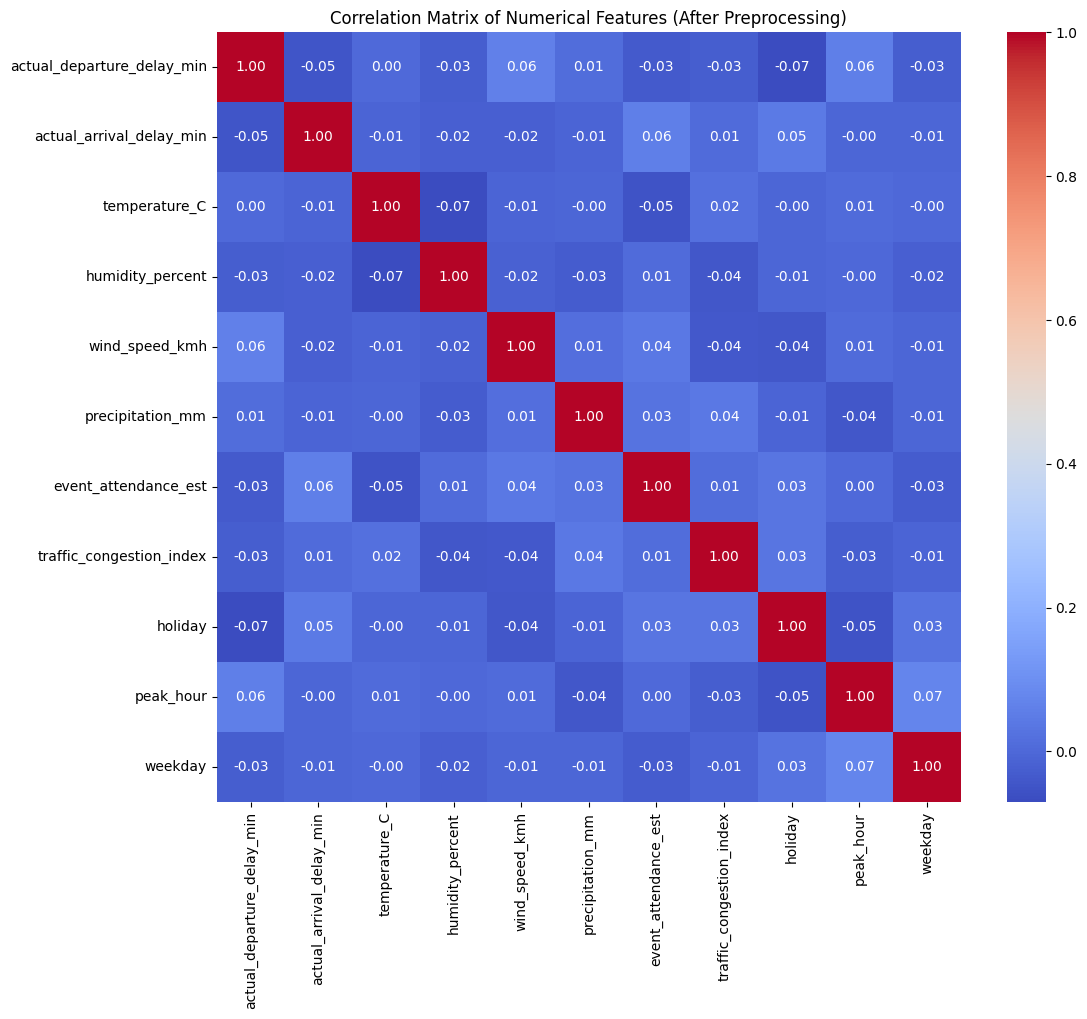

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

post_processed_numerical_cols = [
    'actual_departure_delay_min', 'actual_arrival_delay_min',
    'temperature_C', 'humidity_percent', 'wind_speed_kmh',
    'precipitation_mm', 'event_attendance_est', 'traffic_congestion_index',
    'holiday', 'peak_hour', 'weekday'
]

existing_cols = [col for col in post_processed_numerical_cols if col in X_selected_df.columns]

plt.figure(figsize=(12, 10))
sns.heatmap(X_selected_df[existing_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features (After Preprocessing)')
plt.show()

# Model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_resampled_final, y_resampled_final, test_size=0.2, random_state=42)

model_lr = LogisticRegression(random_state=42, solver='liblinear')

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

print("Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Model Performance:
Accuracy: 0.9634

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       113
           1       1.00      0.93      0.96       133

    accuracy                           0.96       246
   macro avg       0.96      0.97      0.96       246
weighted avg       0.97      0.96      0.96       246


Confusion Matrix:
[[113   0]
 [  9 124]]


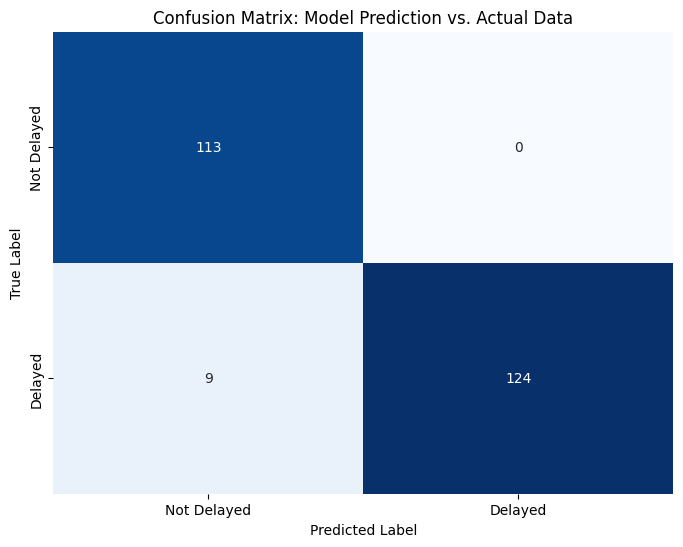

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Delayed', 'Delayed'], yticklabels=['Not Delayed', 'Delayed'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Model Prediction vs. Actual Data')
plt.show()